# 🌧️ Análise CEMADEN — Integração e Comparação de Fontes
## TCC · Henrique Nascimento Santos

**Objetivo:** Integrar os dados de pluviômetros do CEMADEN ao dataset base,  
comparar com ERA5 (Open-Meteo), avaliar qualidade e cobertura espacial,  
e investigar o valor preditivo adicional da rede local de pluviômetros.

**Fontes:**
- `cemaden_sp_diario.csv` — série diária consolidada (CEMADEN, ~80 estações em SP)
- `cemaden_estacoes.csv` — metadados espaciais das estações
- `open_meteo_sp.csv` — ERA5 via Open-Meteo (referência de comparação)
- `final_data.csv` — registros de alagamentos CGE (target)


In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from math import radians, cos, sin, asin, sqrt

plt.rcParams.update({
    "figure.dpi": 120, "figure.facecolor": "white",
    "axes.facecolor": "#f9f9f9", "axes.grid": True,
    "grid.alpha": 0.35, "grid.linestyle": "--",
    "axes.spines.top": False, "axes.spines.right": False,
})
BLUE, RED, GREEN, ORANGE, PURPLE = "#378ADD", "#E05252", "#1D9E75", "#EF9F27", "#8B5CF6"

def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    dlat, dlon = radians(lat2-lat1), radians(lon2-lon1)
    a = sin(dlat/2)**2 + cos(radians(lat1))*cos(radians(lat2))*sin(dlon/2)**2
    return 2*R*asin(sqrt(a))

SP_LAT, SP_LON = -23.5505, -46.6333
print("✓ Setup concluído.")


✓ Setup concluído.


## 1. Carregamento dos Dados

In [2]:
# ── Paths (ajuste conforme sua estrutura) ─────────────────────────────────
BASE = "../../data/outputs/datasets"

PATH_CEMADEN_DIARIO   = f"{BASE}/cemaden_sp_diario.csv"
PATH_CEMADEN_ESTACOES = f"{BASE}/cemaden_estacoes.csv"
PATH_METEO            = f"{BASE}/open_meteo_sp.csv"
PATH_ALAG             = f"{BASE}/final_data.csv"

# ── Alagamentos (target) ──────────────────────────────────────────────────
alag_raw = pd.read_csv(PATH_ALAG)
alag_raw["date"] = pd.to_datetime(alag_raw["date"], format="%d-%m-%Y", errors="coerce")

alag_daily = (
    alag_raw.groupby("date")
    .agg(
        n_events       = ("current_zone", "count"),
        n_intransit    = ("status", lambda x: (x == "Inativo Intransitável").sum()),
        has_flooding   = ("current_zone", lambda x: int(x.notna().any())),
    ).reset_index()
)
all_days = pd.DataFrame({"date": pd.date_range("2015-01-01", "2026-05-31")})
alag_daily = pd.merge(all_days, alag_daily, on="date", how="left")
alag_daily["has_flooding"] = alag_daily["has_flooding"].fillna(0).astype(int)
alag_daily[["n_events","n_intransit"]] = alag_daily[["n_events","n_intransit"]].fillna(0)

# ── CEMADEN ───────────────────────────────────────────────────────────────
cemaden = pd.read_csv(PATH_CEMADEN_DIARIO, parse_dates=["date"])
estacoes = pd.read_csv(PATH_CEMADEN_ESTACOES)

# ── Open-Meteo ────────────────────────────────────────────────────────────
meteo = pd.read_csv(PATH_METEO, parse_dates=["date"])

# ── Dataset unificado ─────────────────────────────────────────────────────
df = (alag_daily
      .merge(cemaden, on="date", how="left")
      .merge(meteo[["date","precipitation_sum","soil_moisture_0_to_7cm_mean",
                    "precipitation_sum_acc3d","precipitation_sum_acc7d"]], on="date", how="left"))

df["month"] = df["date"].dt.month
df["year"]  = df["date"].dt.year

print(f"✓ Dataset unificado: {df.shape[0]:,} linhas × {df.shape[1]} colunas")
print(f"  Período        : {df['date'].min().date()} → {df['date'].max().date()}")
print(f"  Estações CEMADEN: {len(estacoes)}")

# Colunas CEMADEN disponíveis
cem_cols = [c for c in cemaden.columns if c.startswith("cemaden_")]
print(f"  Colunas CEMADEN : {cem_cols}")


✓ Dataset unificado: 4,169 linhas × 22 colunas
  Período        : 2015-01-01 → 2026-05-31
  Estações CEMADEN: 95
  Colunas CEMADEN : ['cemaden_precip_idw_mm', 'cemaden_precip_mean_mm', 'cemaden_precip_max_mm', 'cemaden_precip_median_mm', 'cemaden_intensity_max_hor', 'cemaden_n_estacoes', 'cemaden_precip_lag1d', 'cemaden_precip_lag2d', 'cemaden_precip_lag3d', 'cemaden_precip_acc3d', 'cemaden_precip_acc7d', 'cemaden_precip_acc14d']


## 2. Cobertura Temporal — Gaps e Qualidade

In [3]:
# Relatório de cobertura
MAIN_COL = "cemaden_precip_idw_mm" if "cemaden_precip_idw_mm" in df.columns else "cemaden_precip_mean_mm"

df["month_period"] = df["date"].dt.to_period("M")
monthly_coverage = df.groupby("month_period")[MAIN_COL].apply(
    lambda x: x.notna().mean() * 100
).reset_index(name="cobertura_pct")
monthly_coverage["ano"]  = monthly_coverage["month_period"].dt.year
monthly_coverage["mes"]  = monthly_coverage["month_period"].dt.month

print("=== Cobertura mensal CEMADEN ===")
print(f"Meses com cobertura 100%  : {(monthly_coverage['cobertura_pct']==100).sum()}")
print(f"Meses com cobertura 0%    : {(monthly_coverage['cobertura_pct']==0).sum()} ← arquivos faltando")
print(f"Meses com cobertura parcial: {((monthly_coverage['cobertura_pct']>0) & (monthly_coverage['cobertura_pct']<100)).sum()}")
print()

# Listar meses sem dados
sem_dados = monthly_coverage[monthly_coverage["cobertura_pct"] == 0]
if not sem_dados.empty:
    MESES = ["Jan","Fev","Mar","Abr","Mai","Jun","Jul","Ago","Set","Out","Nov","Dez"]
    print("Meses sem dados CEMADEN (baixar em downpluv.php):")
    for _, r in sem_dados.iterrows():
        print(f"  → {MESES[int(r['mes'])-1]}/{int(r['ano'])}  ({int(r['ano'])}-{int(r['mes']):02d})")


=== Cobertura mensal CEMADEN ===
Meses com cobertura 100%  : 136
Meses com cobertura 0%    : 0 ← arquivos faltando
Meses com cobertura parcial: 1



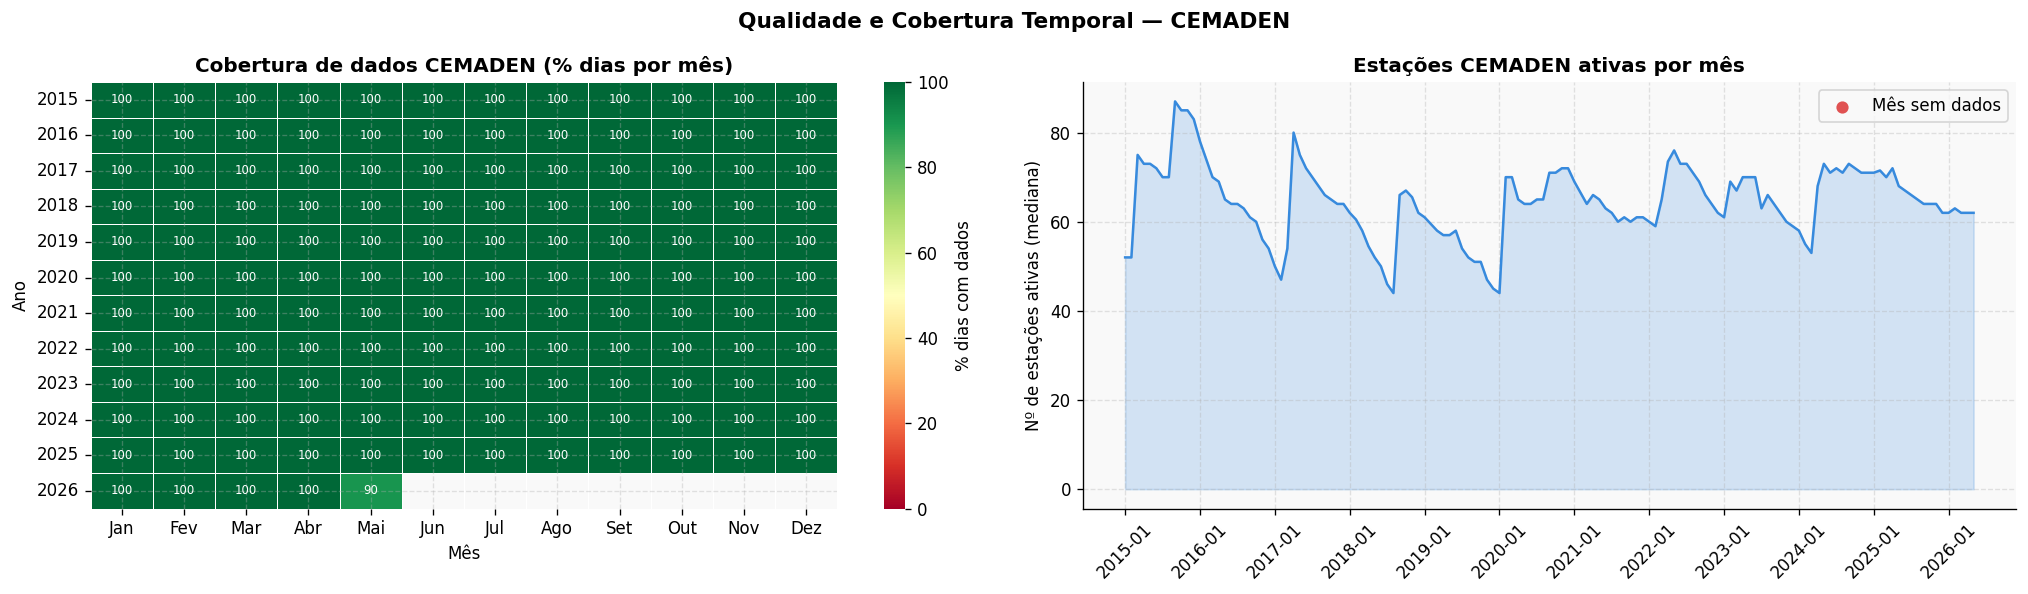

In [4]:
# Heatmap de cobertura mês × ano
fig, axes = plt.subplots(1, 2, figsize=(17, 5))

# Pivô de cobertura
pivot = monthly_coverage.pivot(index="ano", columns="mes", values="cobertura_pct")
pivot.columns = ["Jan","Fev","Mar","Abr","Mai","Jun","Jul","Ago","Set","Out","Nov","Dez"]

sns.heatmap(pivot, ax=axes[0], cmap="RdYlGn", vmin=0, vmax=100,
            annot=True, fmt=".0f", linewidths=0.5, annot_kws={"size": 7},
            cbar_kws={"label": "% dias com dados"})
axes[0].set_title("Cobertura de dados CEMADEN (% dias por mês)", fontweight="bold")
axes[0].set_xlabel("Mês"); axes[0].set_ylabel("Ano")

# Número de estações ativas por mês
n_col = "cemaden_n_estacoes" if "cemaden_n_estacoes" in df.columns else None
if n_col:
    monthly_stations = df.groupby("month_period")[n_col].median().reset_index()
    monthly_stations["label"] = monthly_stations["month_period"].astype(str)
    axes[1].plot(range(len(monthly_stations)), monthly_stations[n_col],
                 color=BLUE, linewidth=1.5)
    axes[1].fill_between(range(len(monthly_stations)), monthly_stations[n_col],
                         alpha=0.2, color=BLUE)
    # Marcar gaps (0 estações)
    gap_idx = monthly_stations[monthly_stations[n_col] == 0].index
    axes[1].scatter(gap_idx, [0]*len(gap_idx), color=RED, zorder=5, s=40, label="Mês sem dados")
    axes[1].set_ylabel("Nº de estações ativas (mediana)")
    axes[1].set_title("Estações CEMADEN ativas por mês", fontweight="bold")
    # Labels a cada 12 meses
    tick_idx = list(range(0, len(monthly_stations), 12))
    axes[1].set_xticks(tick_idx)
    axes[1].set_xticklabels([monthly_stations["label"].iloc[i] for i in tick_idx], rotation=45)
    axes[1].legend()
else:
    axes[1].text(0.5, 0.5, "cemaden_n_estacoes não disponível", transform=axes[1].transAxes, ha="center")

plt.suptitle("Qualidade e Cobertura Temporal — CEMADEN", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


## 3. Análise Espacial das Estações CEMADEN

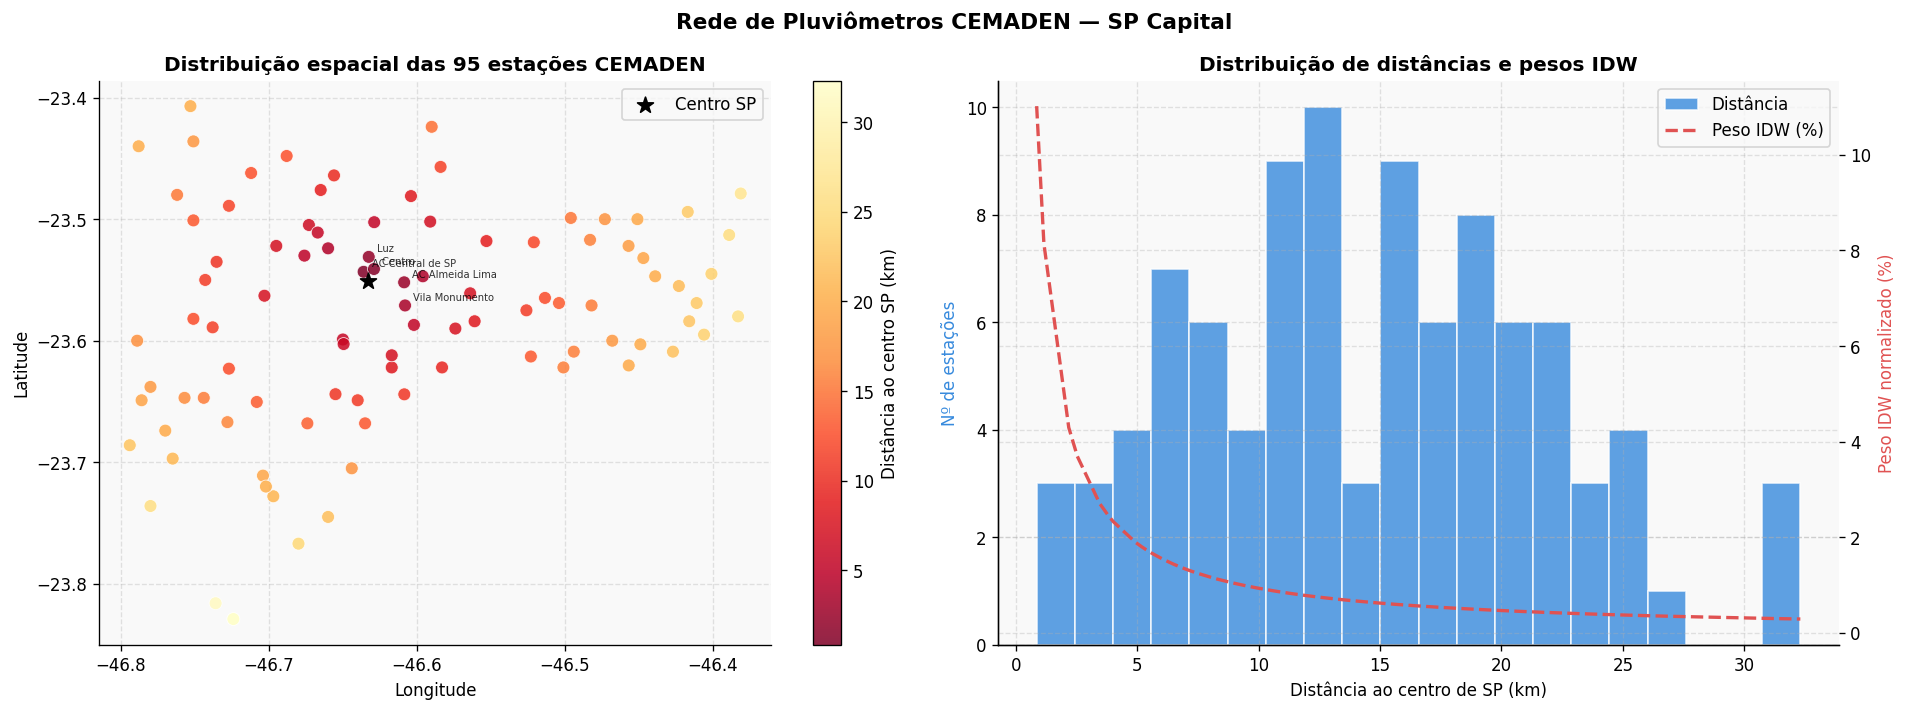

Distância média das estações ao centro: 14.5 km
Estação mais próxima : AC Central de SP (0.8 km)
Estação mais distante: C.E.U Parelheiros (32.3 km)


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Calcular distâncias se não existirem
if "dist_sp_km" not in estacoes.columns:
    estacoes["dist_sp_km"] = estacoes.apply(
        lambda r: haversine(r["lat"], r["lon"], SP_LAT, SP_LON)
        if pd.notna(r["lat"]) else np.nan, axis=1
    )

# 3.1 Scatter espacial das estações
ax = axes[0]
sc = ax.scatter(estacoes["lon"], estacoes["lat"],
                c=estacoes["dist_sp_km"], cmap="YlOrRd_r",
                s=60, alpha=0.85, edgecolors="white", linewidth=0.5, zorder=3)
plt.colorbar(sc, ax=ax, label="Distância ao centro SP (km)")
ax.scatter([SP_LON], [SP_LAT], color="black", s=100, marker="*",
           zorder=5, label="Centro SP")
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
ax.set_title(f"Distribuição espacial das {len(estacoes)} estações CEMADEN", fontweight="bold")
ax.legend()

# Anotar as 5 mais próximas
top5 = estacoes.nsmallest(5, "dist_sp_km")
for _, row in top5.iterrows():
    ax.annotate(row["nome_estacao"], (row["lon"], row["lat"]),
                textcoords="offset points", xytext=(5, 3), fontsize=6, alpha=0.8)

# 3.2 Histograma de distâncias + IDW weight
ax = axes[1]
ax.hist(estacoes["dist_sp_km"].dropna(), bins=20, color=BLUE, alpha=0.8,
        edgecolor="white", label="Distância")
ax2 = ax.twinx()
dist_sorted = estacoes["dist_sp_km"].dropna().sort_values()
weights = (1/dist_sorted) / (1/dist_sorted).sum() * 100
ax2.plot(dist_sorted.values, weights.values, color=RED, linewidth=2,
         linestyle="--", label="Peso IDW (%)")
ax.set_xlabel("Distância ao centro de SP (km)")
ax.set_ylabel("Nº de estações", color=BLUE)
ax2.set_ylabel("Peso IDW normalizado (%)", color=RED)
ax.set_title("Distribuição de distâncias e pesos IDW", fontweight="bold")
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1+lines2, labels1+labels2, loc="upper right")

plt.suptitle("Rede de Pluviômetros CEMADEN — SP Capital", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"Distância média das estações ao centro: {estacoes['dist_sp_km'].mean():.1f} km")
print(f"Estação mais próxima : {estacoes.nsmallest(1,'dist_sp_km').iloc[0]['nome_estacao']} ({estacoes['dist_sp_km'].min():.1f} km)")
print(f"Estação mais distante: {estacoes.nlargest(1,'dist_sp_km').iloc[0]['nome_estacao']} ({estacoes['dist_sp_km'].max():.1f} km)")


## 4. Comparação CEMADEN vs Open-Meteo (ERA5)

In [6]:
# Apenas dias com dados em ambas as fontes
df_comp = df[df[MAIN_COL].notna() & df["precipitation_sum"].notna()].copy()
print(f"Dias com ambas as fontes: {len(df_comp):,}")

# Correlação entre as séries
r, p = stats.pearsonr(df_comp[MAIN_COL], df_comp["precipitation_sum"])
rho, _ = stats.spearmanr(df_comp[MAIN_COL], df_comp["precipitation_sum"])
print(f"Correlação Pearson  (IDW CEMADEN × ERA5): r = {r:.3f}  p = {p:.2e}")
print(f"Correlação Spearman (IDW CEMADEN × ERA5): ρ = {rho:.3f}")
print()

# Diferenças
diff = df_comp[MAIN_COL] - df_comp["precipitation_sum"]
print("Diferença CEMADEN − ERA5:")
print(f"  Média  : {diff.mean():+.2f} mm  (bias)")
print(f"  Mediana: {diff.median():+.2f} mm")
print(f"  RMSE   : {np.sqrt((diff**2).mean()):.2f} mm")
print(f"  MAE    : {diff.abs().mean():.2f} mm")


Dias com ambas as fontes: 4,166
Correlação Pearson  (IDW CEMADEN × ERA5): r = 0.229  p = 1.69e-50
Correlação Spearman (IDW CEMADEN × ERA5): ρ = 0.765

Diferença CEMADEN − ERA5:
  Média  : -0.10 mm  (bias)
  Mediana: +0.01 mm
  RMSE   : 18.12 mm
  MAE    : 2.87 mm


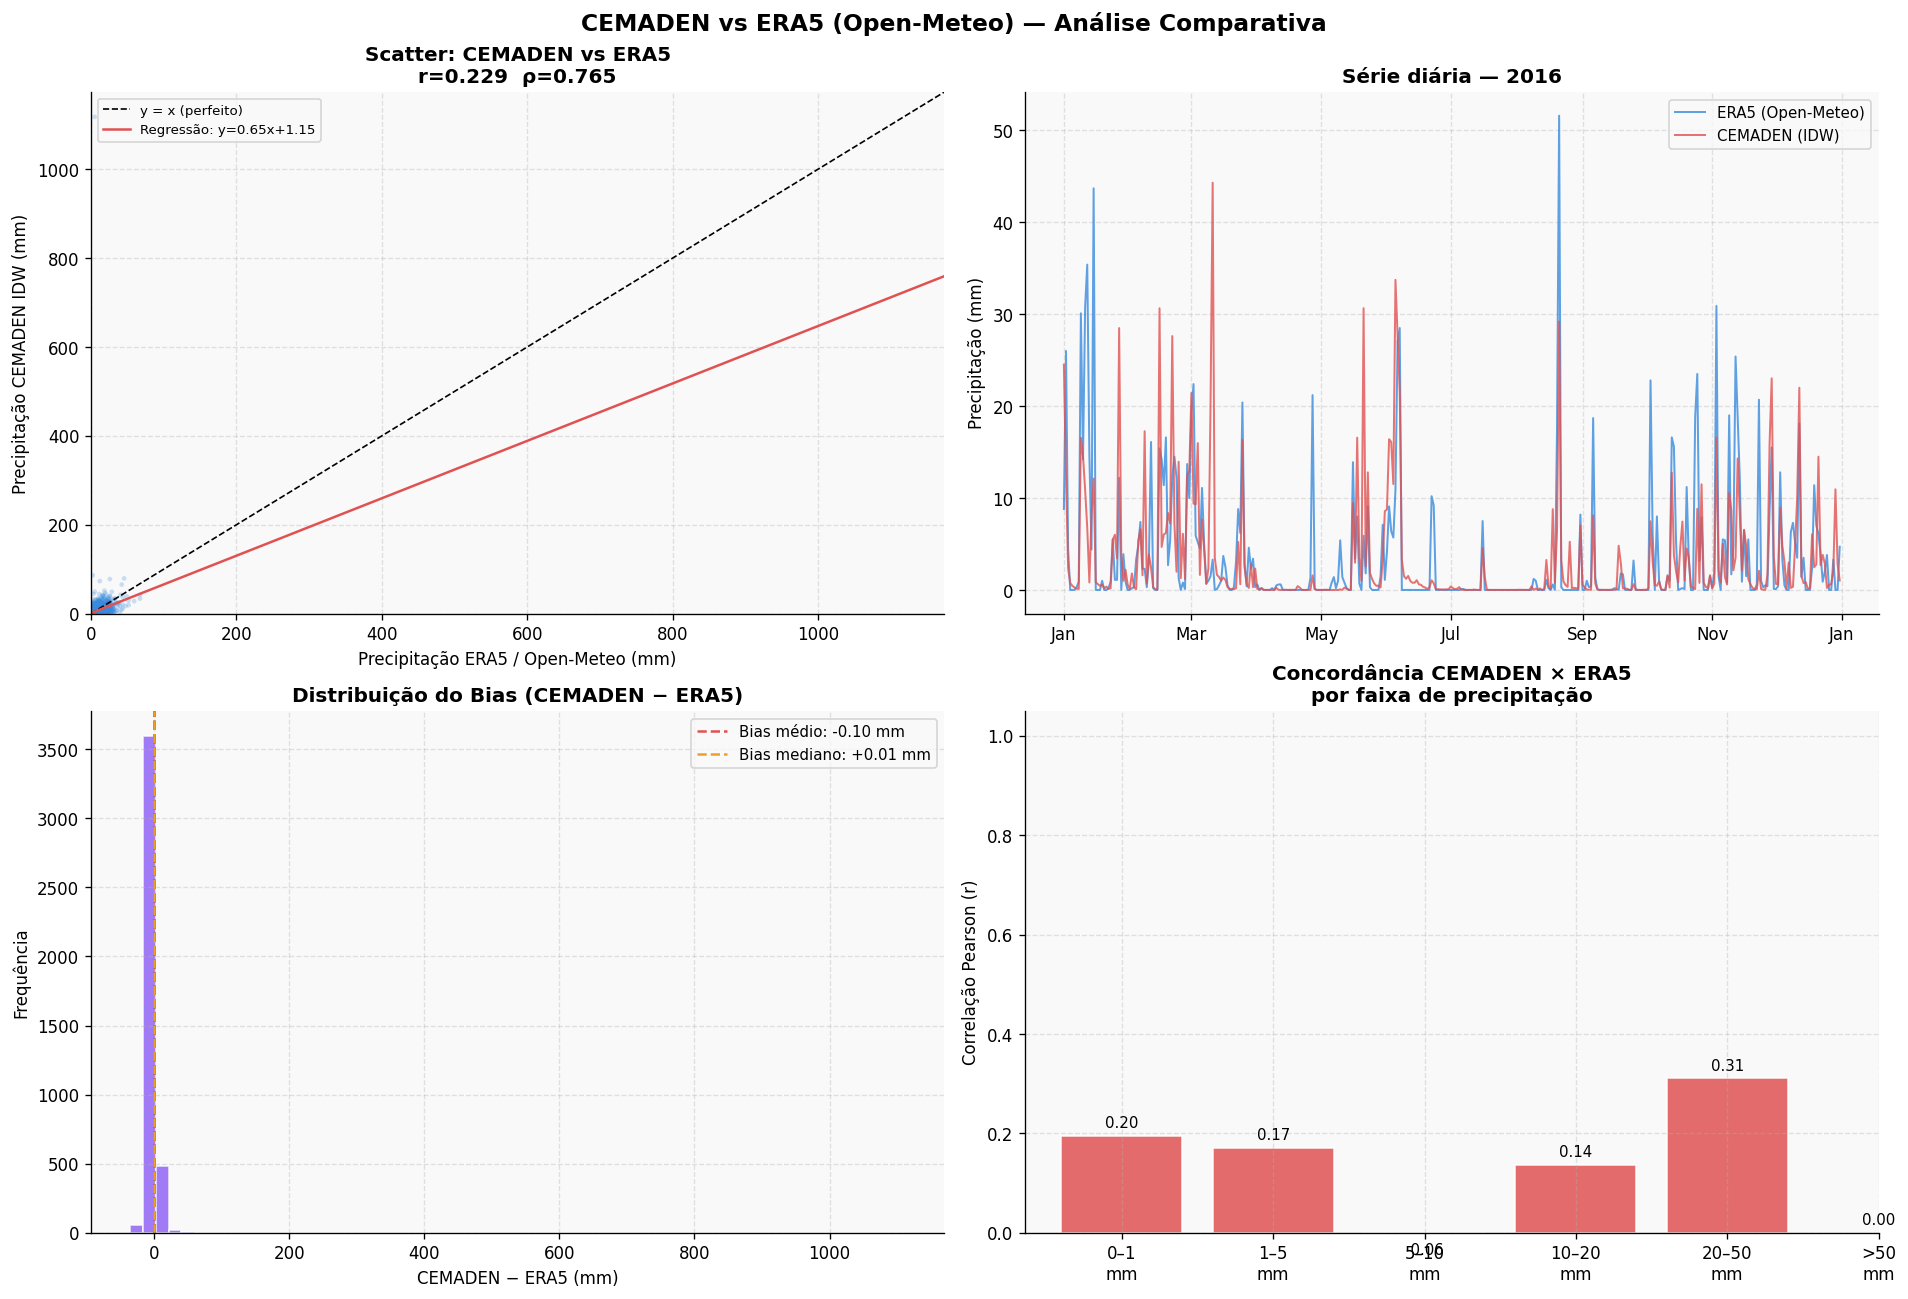

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# 4.1 Scatter CEMADEN vs ERA5
ax = axes[0, 0]
ax.scatter(df_comp["precipitation_sum"], df_comp[MAIN_COL],
           alpha=0.25, s=8, color=BLUE, edgecolors="none")
lim = max(df_comp["precipitation_sum"].max(), df_comp[MAIN_COL].max()) * 1.05
ax.plot([0, lim], [0, lim], "k--", linewidth=1, label="y = x (perfeito)")
# Linha de regressão
m, b = np.polyfit(df_comp["precipitation_sum"], df_comp[MAIN_COL], 1)
x_line = np.linspace(0, lim, 100)
ax.plot(x_line, m*x_line+b, color=RED, linewidth=1.5, label=f"Regressão: y={m:.2f}x+{b:.2f}")
ax.set_xlabel("Precipitação ERA5 / Open-Meteo (mm)")
ax.set_ylabel(f"Precipitação CEMADEN IDW (mm)")
ax.set_title(f"Scatter: CEMADEN vs ERA5\nr={r:.3f}  ρ={rho:.3f}", fontweight="bold")
ax.legend(fontsize=8)
ax.set_xlim(0, lim); ax.set_ylim(0, lim)

# 4.2 Série temporal comparativa (zoom 1 ano)
ax = axes[0, 1]
year_filter = df_comp["year"] == df_comp["year"].value_counts().idxmax()
df_yr = df_comp[year_filter].sort_values("date")
ax.plot(df_yr["date"], df_yr["precipitation_sum"], color=BLUE, linewidth=1.2,
        alpha=0.8, label="ERA5 (Open-Meteo)")
ax.plot(df_yr["date"], df_yr[MAIN_COL], color=RED, linewidth=1.2,
        alpha=0.8, label="CEMADEN (IDW)")
ax.set_ylabel("Precipitação (mm)")
ax.set_title(f"Série diária — {df_yr['year'].iloc[0]}", fontweight="bold")
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))

# 4.3 Distribuição de bias
ax = axes[1, 0]
diff_vals = df_comp[MAIN_COL] - df_comp["precipitation_sum"]
ax.hist(diff_vals, bins=60, color=PURPLE, alpha=0.8, edgecolor="white")
ax.axvline(0, color="black", linestyle="--", linewidth=1.5)
ax.axvline(diff_vals.mean(), color=RED, linestyle="--", linewidth=1.5,
           label=f"Bias médio: {diff_vals.mean():+.2f} mm")
ax.axvline(diff_vals.median(), color=ORANGE, linestyle="--", linewidth=1.5,
           label=f"Bias mediano: {diff_vals.median():+.2f} mm")
ax.set_xlabel("CEMADEN − ERA5 (mm)")
ax.set_ylabel("Frequência")
ax.set_title("Distribuição do Bias (CEMADEN − ERA5)", fontweight="bold")
ax.legend(fontsize=9)

# 4.4 Concordância por faixas de precipitação
ax = axes[1, 1]
bins_precip = [0, 1, 5, 10, 20, 50, 200]
labels_bins = ["0–1","1–5","5–10","10–20","20–50",">50"]
df_comp["faixa_era5"] = pd.cut(df_comp["precipitation_sum"], bins=bins_precip, labels=labels_bins)
concordance = df_comp.groupby("faixa_era5", observed=True).apply(
    lambda g: stats.pearsonr(g["precipitation_sum"], g[MAIN_COL])[0]
    if len(g) > 5 else np.nan
).reset_index(name="pearson_r")
bars = ax.bar(range(len(concordance)), concordance["pearson_r"],
              color=[GREEN if v > 0.7 else ORANGE if v > 0.4 else RED
                     for v in concordance["pearson_r"].fillna(0)],
              alpha=0.85, edgecolor="white")
ax.set_xticks(range(len(concordance)))
ax.set_xticklabels([f"{l}\nmm" for l in labels_bins])
ax.set_ylabel("Correlação Pearson (r)")
ax.set_ylim(0, 1.05)
ax.set_title("Concordância CEMADEN × ERA5\npor faixa de precipitação", fontweight="bold")
for bar, v in zip(bars, concordance["pearson_r"].fillna(0)):
    ax.text(bar.get_x()+bar.get_width()/2, v+0.01, f"{v:.2f}",
            ha="center", va="bottom", fontsize=9)

plt.suptitle("CEMADEN vs ERA5 (Open-Meteo) — Análise Comparativa", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


## 5. Variabilidade Espacial — Dispersão entre Estações

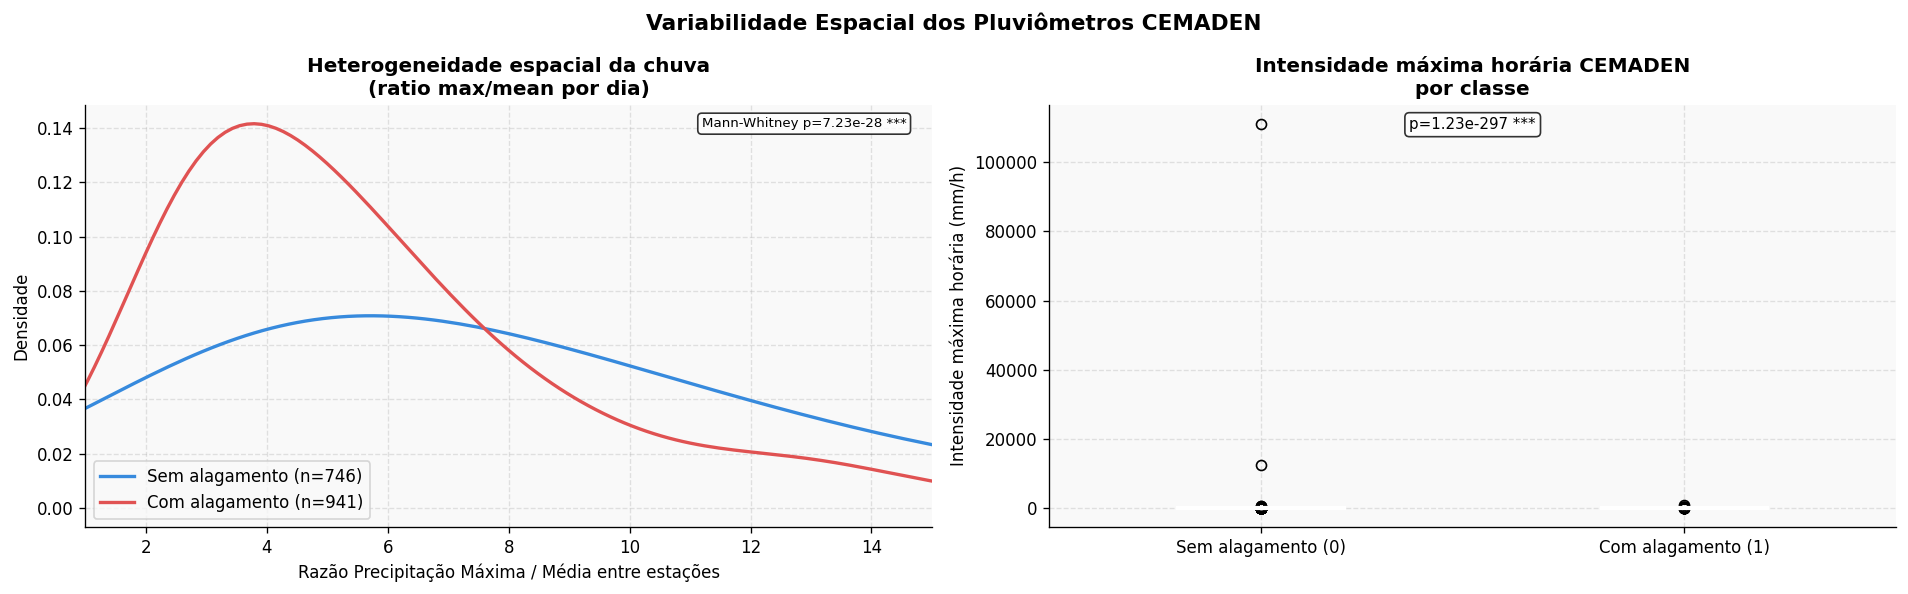

In [8]:
# Carregar dados brutos para calcular dispersão espacial diária
# (requer que o consolidate_cemaden.py tenha salvo cemaden_sp_diario com n_estacoes e max/mean)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 5.1 Razão max/mean — proxy de heterogeneidade espacial da chuva
if "cemaden_precip_max_mm" in df.columns and "cemaden_precip_mean_mm" in df.columns:
    df_with_rain = df[(df["cemaden_precip_mean_mm"] > 1) & df["cemaden_precip_max_mm"].notna()].copy()
    df_with_rain["razao_max_mean"] = df_with_rain["cemaden_precip_max_mm"] / df_with_rain["cemaden_precip_mean_mm"]

    # Por classe
    ax = axes[0]
    for cls, color, lbl in [(0, BLUE, "Sem alagamento"), (1, RED, "Com alagamento")]:
        vals = df_with_rain[df_with_rain["has_flooding"]==cls]["razao_max_mean"].dropna()
        vals.plot.kde(ax=ax, color=color, linewidth=2, label=f"{lbl} (n={len(vals):,})")
    ax.axvline(1, color="gray", linestyle="--", linewidth=1)
    ax.set_xlabel("Razão Precipitação Máxima / Média entre estações")
    ax.set_ylabel("Densidade")
    ax.set_title("Heterogeneidade espacial da chuva\n(ratio max/mean por dia)", fontweight="bold")
    ax.legend()
    ax.set_xlim(1, 15)

    # Mann-Whitney test
    s0 = df_with_rain[df_with_rain["has_flooding"]==0]["razao_max_mean"].dropna()
    s1 = df_with_rain[df_with_rain["has_flooding"]==1]["razao_max_mean"].dropna()
    stat, p = stats.mannwhitneyu(s0, s1)
    sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"
    ax.text(0.97, 0.97, f"Mann-Whitney p={p:.2e} {sig}",
            transform=ax.transAxes, ha="right", va="top", fontsize=8,
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))

# 5.2 Nº de estações com chuva intensa (>10mm) no dia
ax = axes[1]
if "cemaden_precip_max_mm" in df.columns:
    # Estações com leitura alta = proxy para eventos convectivos localizados
    df["max_hor"] = df.get("cemaden_intensity_max_hor", df.get("cemaden_precip_max_mm"))
    by_class = df.groupby("has_flooding")["max_hor"].apply(
        lambda x: x.dropna().tolist()
    )
    bp = ax.boxplot([by_class.get(0, []), by_class.get(1, [])],
                    patch_artist=True, widths=0.4,
                    medianprops=dict(color="white", linewidth=2.5))
    bp["boxes"][0].set_facecolor(BLUE); bp["boxes"][1].set_facecolor(RED)
    ax.set_xticklabels(["Sem alagamento (0)", "Com alagamento (1)"])
    ax.set_ylabel("Intensidade máxima horária (mm/h)")
    ax.set_title("Intensidade máxima horária CEMADEN\npor classe", fontweight="bold")
    stat, p = stats.mannwhitneyu(by_class.get(0,[]), by_class.get(1,[]), alternative="two-sided")
    sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"
    ax.text(0.5, 0.97, f"p={p:.2e} {sig}", transform=ax.transAxes,
            ha="center", va="top", fontsize=9,
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))

plt.suptitle("Variabilidade Espacial dos Pluviômetros CEMADEN", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


## 6. Correlações das Variáveis CEMADEN com o Target

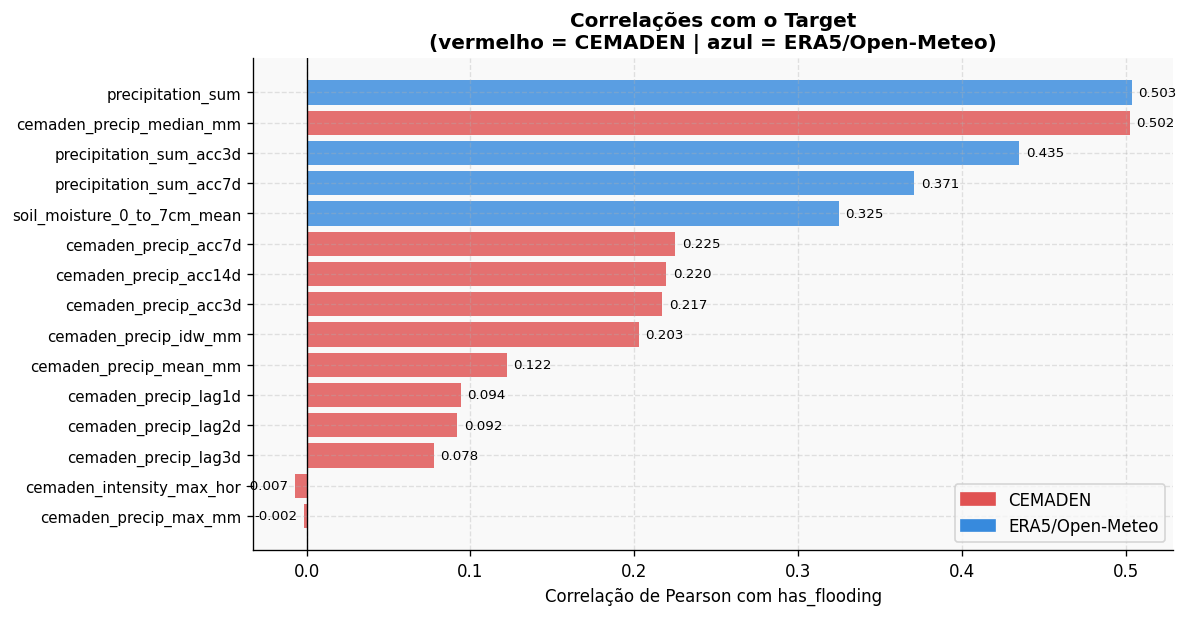


Top features por correlação com has_flooding:
  [ERA5  ] precipitation_sum                             r = +0.503
  [CEMADEN] cemaden_precip_median_mm                      r = +0.502
  [ERA5  ] precipitation_sum_acc3d                       r = +0.435
  [ERA5  ] precipitation_sum_acc7d                       r = +0.371
  [ERA5  ] soil_moisture_0_to_7cm_mean                   r = +0.325
  [CEMADEN] cemaden_precip_acc7d                          r = +0.225
  [CEMADEN] cemaden_precip_acc14d                         r = +0.220
  [CEMADEN] cemaden_precip_acc3d                          r = +0.217
  [CEMADEN] cemaden_precip_idw_mm                         r = +0.203
  [CEMADEN] cemaden_precip_mean_mm                        r = +0.122
  [CEMADEN] cemaden_precip_lag1d                          r = +0.094
  [CEMADEN] cemaden_precip_lag2d                          r = +0.092
  [CEMADEN] cemaden_precip_lag3d                          r = +0.078
  [CEMADEN] cemaden_intensity_max_hor                     r 

In [9]:
# Comparar correlações CEMADEN × ERA5 com has_flooding
cem_features = [c for c in df.columns if c.startswith("cemaden_") and c != "cemaden_n_estacoes"]
era5_features = ["precipitation_sum", "precipitation_sum_acc3d",
                 "precipitation_sum_acc7d", "soil_moisture_0_to_7cm_mean"]

all_features = cem_features + era5_features
corr_df = (df[all_features + ["has_flooding"]]
           .corrwith(df["has_flooding"])
           .drop("has_flooding")
           .sort_values(key=abs, ascending=True))

fig, ax = plt.subplots(figsize=(10, max(5, len(corr_df)*0.35)))
colors = []
for idx in corr_df.index:
    if idx.startswith("cemaden_"): colors.append(RED)
    else: colors.append(BLUE)

bars = ax.barh(range(len(corr_df)), corr_df.values, color=colors, alpha=0.82)
ax.set_yticks(range(len(corr_df)))
ax.set_yticklabels(corr_df.index, fontsize=9)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Correlação de Pearson com has_flooding")
ax.set_title("Correlações com o Target\n(vermelho = CEMADEN | azul = ERA5/Open-Meteo)", fontweight="bold")
for i, v in enumerate(corr_df.values):
    ax.text(v + (0.004 if v >= 0 else -0.004), i,
            f"{v:.3f}", va="center", ha="left" if v >= 0 else "right", fontsize=8)

# Legenda manual
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=RED, label="CEMADEN"), Patch(color=BLUE, label="ERA5/Open-Meteo")],
          loc="lower right")
plt.tight_layout()
plt.show()

print("\nTop features por correlação com has_flooding:")
full_corr = corr_df.sort_values(key=abs, ascending=False)
for feat, val in full_corr.items():
    fonte = "CEMADEN" if feat.startswith("cemaden_") else "ERA5  "
    print(f"  [{fonte}] {feat:45s} r = {val:+.3f}")


## 7. Dataset Final Integrado — Visão Geral

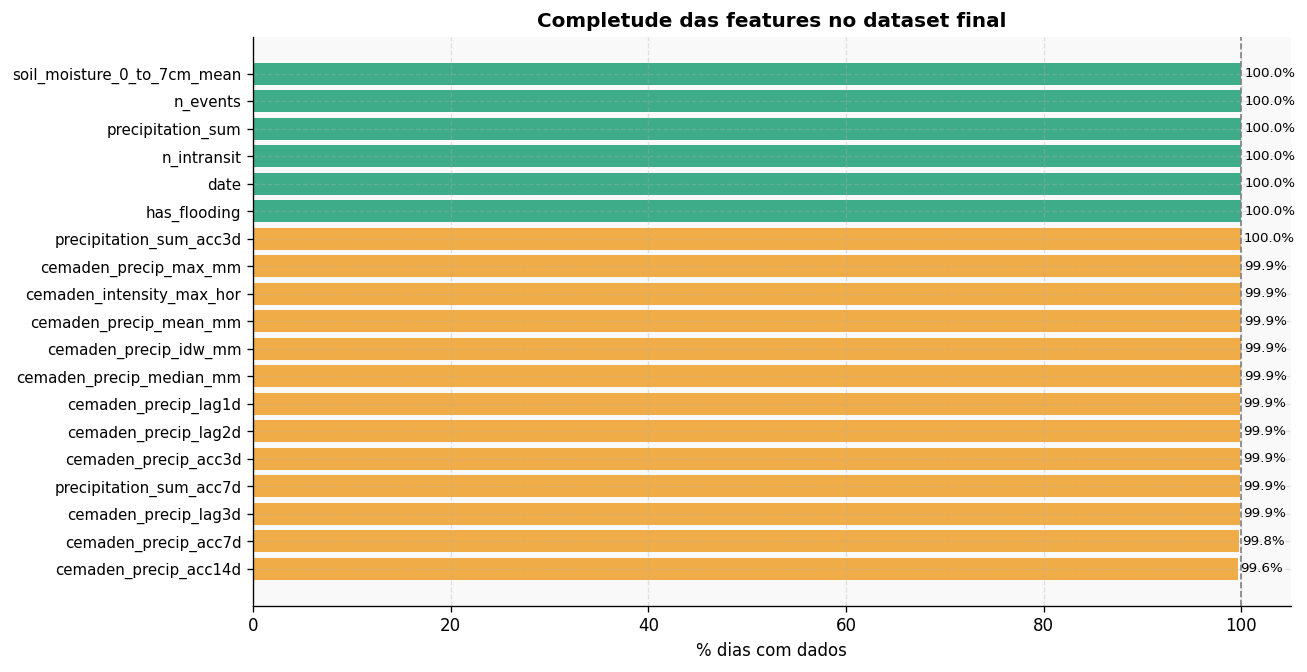


Resumo do dataset final para modelagem:
  Linhas  : 4,169
  Features: 15
  Target  : 1,031 positivos (24.7%)

Completude por feature:
  ✓ soil_moisture_0_to_7cm_mean                        100.0%
  ✓ precipitation_sum                                  100.0%
  ⚠ precipitation_sum_acc3d                            100.0%
  ⚠ cemaden_precip_median_mm                           99.9%
  ⚠ cemaden_precip_idw_mm                              99.9%
  ⚠ cemaden_precip_mean_mm                             99.9%
  ⚠ cemaden_intensity_max_hor                          99.9%
  ⚠ cemaden_precip_max_mm                              99.9%
  ⚠ cemaden_precip_lag1d                               99.9%
  ⚠ cemaden_precip_lag2d                               99.9%
  ⚠ cemaden_precip_acc3d                               99.9%
  ⚠ cemaden_precip_lag3d                               99.9%
  ⚠ precipitation_sum_acc7d                            99.9%
  ⚠ cemaden_precip_acc7d                               99.8%
  ⚠ cema

In [10]:
# Construir dataset final para modelagem
FINAL_FEATURES = (
    [c for c in df.columns if c.startswith("cemaden_") and "n_estacoes" not in c]
    + ["precipitation_sum", "precipitation_sum_acc3d", "precipitation_sum_acc7d",
       "soil_moisture_0_to_7cm_mean"]
)

df_final = df[["date","has_flooding","n_events","n_intransit"] + FINAL_FEATURES].copy()

# Completude por coluna
completude = (df_final.notna().mean() * 100).sort_values()
fig, ax = plt.subplots(figsize=(11, max(4, len(completude)*0.3)))
colors_c = [GREEN if v == 100 else ORANGE if v > 50 else RED for v in completude.values]
ax.barh(range(len(completude)), completude.values, color=colors_c, alpha=0.85)
ax.set_yticks(range(len(completude)))
ax.set_yticklabels(completude.index, fontsize=9)
ax.axvline(100, color="gray", linestyle="--", linewidth=1)
ax.set_xlabel("% dias com dados")
ax.set_title("Completude das features no dataset final", fontweight="bold")
for i, v in enumerate(completude.values):
    ax.text(v + 0.3, i, f"{v:.1f}%", va="center", fontsize=8)
plt.tight_layout()
plt.show()

print("\nResumo do dataset final para modelagem:")
print(f"  Linhas  : {len(df_final):,}")
print(f"  Features: {len(FINAL_FEATURES)}")
print(f"  Target  : {df_final['has_flooding'].sum():,} positivos ({df_final['has_flooding'].mean()*100:.1f}%)")
print()
print("Completude por feature:")
for feat, pct in completude.sort_values(ascending=False).items():
    if feat not in ["date","has_flooding","n_events","n_intransit"]:
        status = "✓" if pct == 100 else "⚠" if pct > 50 else "✗"
        print(f"  {status} {feat:50s} {pct:.1f}%")


In [11]:
# Salvar dataset final integrado
OUTPUT_PATH = f"{BASE}/dataset_final_integrado.csv"
df_final.to_csv(OUTPUT_PATH, index=False)
print(f"✓ Dataset final salvo em '{OUTPUT_PATH}'")
print(f"  Shape: {df_final.shape}")


✓ Dataset final salvo em '../../data/outputs/datasets/dataset_final_integrado.csv'
  Shape: (4169, 19)


## 8. Conclusões — Integração CEMADEN

### O que a rede CEMADEN adiciona ao ERA5

| Aspecto | ERA5 (Open-Meteo) | CEMADEN |
|---|---|---|
| Resolução espacial | ~9 km (grade) | ~3–5 km (80 pontos em SP) |
| Resolução temporal | Horária → diária | Horária (acumulado) |
| Cobertura histórica | 2015–2026 completo | Depende dos downloads |
| Variável principal | `precipitation_sum` | `cemaden_precip_idw_mm` |
| Informação extra | Umidade solo, ET0, vento | Intensidade máxima horária, variabilidade espacial |

### Decisão para modelagem
- **Se cobertura CEMADEN ≥ 80%:** usar `cemaden_precip_idw_mm` como feature principal e `precipitation_sum` (ERA5) como complemento para dias sem dados.
- **Se cobertura < 80%:** usar ERA5 como principal e CEMADEN como feature adicional, imputando `NaN` com a média ou valor ERA5.
- A **intensidade máxima horária** (`cemaden_intensity_max_hor`) captura eventos convectivos localizados que a média IDW suaviza — vale testar como feature independente.

### Próximos passos
- [ ] Completar download dos meses com gaps (ver `cemaden_relatorio_gaps.txt`)
- [ ] Modelagem com XGBoost / LightGBM usando dataset final integrado
- [ ] Avaliar ganho de performance: modelo com CEMADEN vs sem CEMADEN
- [ ] Threshold tuning focado em maximizar Recall (falso negativo = não alertar)
